In [220]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error

import pickle

### Data Loading and Preparation

In [221]:
from google.colab import files

In [222]:
# Load the Airbnb dataset
data = pd.read_excel('/content/drive/MyDrive/DSA Folder/Dataset/partpdf_1772778618075_partpdf_1763620814447_airbnb.xlsx')

In [223]:
data.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,500,2008-06-26,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
1,500,2008-06-26,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0
2,1039,2008-07-25,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0
3,1783,2008-08-12,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250,100.0
4,2078,2008-08-15,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90,94.0


In [224]:
# Inspect the dataset
data.info()

# Convert the 'Host Since' column to datetime
data['Host Since'] = pd.to_datetime(data['Host Since'], errors='coerce')  # Handle errors gracefully

# Check the data type to confirm
print(data['Host Since'].head())
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30475 entries, 0 to 30474
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Host Id                     30475 non-null  int64         
 1   Host Since                  30475 non-null  datetime64[ns]
 2   Name                        30475 non-null  object        
 3   Neighbourhood               30475 non-null  object        
 4   Property Type               30472 non-null  object        
 5   Review Scores Rating (bin)  22155 non-null  float64       
 6   Room Type                   30475 non-null  object        
 7   Zipcode                     30341 non-null  float64       
 8   Beds                        30390 non-null  float64       
 9   Number of Records           30475 non-null  int64         
 10  Number Of Reviews           30475 non-null  int64         
 11  Price                       30475 non-null  int64     

New Feature Creation from Host Since

A valuable feature can be calculated as the "Host Duration" (time difference between the listing date and today). Hosts with more experience might provide better accommodations and earn higher prices. Adding this feature could correlate with price predictions.



### Handling Missing Data

In [225]:
# Check for duplicate rows
data.duplicated().sum()

np.int64(17)

In [226]:
data.drop_duplicates()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,500,2008-06-26,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
1,500,2008-06-26,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0
2,1039,2008-07-25,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0
3,1783,2008-08-12,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250,100.0
4,2078,2008-08-15,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90,94.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30470,43022976,2015-08-31,10 Mins to Time Square/two floors,Queens,Apartment,NaN,Entire home/apt,11101.0,5.0,1,0,300,NaN
30471,42993382,2015-08-31,"1BR ocean view & F,Q train st",Brooklyn,Apartment,NaN,Private room,11224.0,2.0,1,0,125,NaN
30472,43033067,2015-08-31,Amazing Private Room,Brooklyn,Other,NaN,Private room,11206.0,1.0,1,0,80,NaN
30473,43000991,2015-08-31,Charming private female room: UWS,Manhattan,Apartment,NaN,Private room,10025.0,1.0,1,0,35,NaN


In [227]:
# Visualize missing data
data.isnull().sum()

,0
Host Id,0
Host Since,0
Name,0
Neighbourhood,0
Property Type,3
Review Scores Rating (bin),8320
Room Type,0
Zipcode,134
Beds,85
Number of Records,0


In [228]:
# Drop the 'Review Scores Rating (bin)' column
data = data.drop(columns=['Review Scores Rating (bin)'], axis=1)
print("Updated Dataset Columns:")
print(data.columns)

Updated Dataset Columns:
Index(['Host Id', 'Host Since', 'Name', 'Neighbourhood ', 'Property Type',
       'Room Type', 'Zipcode', 'Beds', 'Number of Records',
       'Number Of Reviews', 'Price', 'Review Scores Rating'],
      dtype='object')


In [229]:
# Filling the columns
data['Review Scores Rating'] = data['Review Scores Rating'].fillna(data['Review Scores Rating'].median())
data['Beds'] = data['Beds'].fillna(data['Beds'].mode()[0])
data['Zipcode'] = data['Zipcode'].fillna(data['Zipcode'].mode()[0])
data['Property Type'] = data['Property Type'].fillna(data['Property Type'].mode()[0])

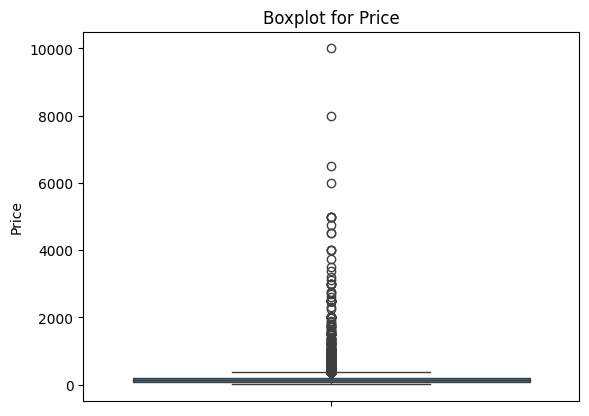

In [230]:
# Plot boxplot for the Price column
sns.boxplot(data['Price'])
plt.title('Boxplot for Price')
plt.show()


In [231]:
# Calculate Interquartile Range (IQR) for Price
Q1 = data['Price'].quantile(0.25)
Q3 = data['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Lower Bound: -92.5, Upper Bound: 367.5


In [232]:
# Filter out outliers
outliers = data[(data['Price'] < lower_bound) | (data['Price'] > upper_bound)]
print(f"Number of outliers in Price: {outliers.shape[0]}")

Number of outliers in Price: 1518


In [233]:
# Optionally remove outliers
data = data[(data['Price'] >= lower_bound) & (data['Price'] <= upper_bound)]
print(f"Data shape after removing outliers: {data.shape}")

Data shape after removing outliers: (28957, 12)


1.Duplicate Values:

Duplicate rows, if present, were removed to ensure that redundant information doesn’t bias the model.

2.Column Removal:

 the Review Scores Rating (bin) column was removed because it is derived from the Review Scores Rating column and adds no unique information to the dataset. Keeping it would introduce redundancy, leading to potential multicollinearity in certain models and unnecessary complexity. Review Scores Rating provides granular numerical data, which is more useful for predictive modeling.

 3.Imputation Strategy:

Review Scores Rating: Imputed with the median as it handles outliers better.
Beds, Zipcode, Property Type: Imputed with the mode because they are categorical columns, and the mode represents the most frequent, logical value.

4.Why Identify Outliers:

Outliers in Price can skew model performance. Prices significantly higher than average may represent luxury listings, while very low prices could be erroneous entries. Treating outliers improves training accuracy.

### Advanced Feature Engineering

In [237]:
# Step 1: Preprocess 'Host Since' (convert to numeric feature: Host Duration)
if 'Host Since' in data.columns:
    data['Host_Duration'] = (pd.Timestamp.now() - data['Host Since']).dt.days
    data = data.drop(columns=['Host Since'])

# Step 2: Drop irrelevant columns like 'Name', unless necessary
if 'Name' in data.columns:
    data = data.drop(columns=['Name'])  # 'Name' is usually irrelevant for predicting price

# Step 3: Check for categorical columns and encode them into numerical data
categorical_columns = data.select_dtypes(include=['object']).columns  # Detect string columns
print(f"Categorical Columns Found: {categorical_columns}")

# Apply one-hot encoding to categorical columns
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# Step 4: Define predictors (X) and target variable (y)
X = data.drop(columns=['Price'], axis=1)  # 'Price' is the target variable
y = data['Price']

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Ensure presence of interaction feature and handle subsets
if 'Neighbourhood_RoomType' in X_train.columns:
    X_train_with = X_train.copy()
    X_train_without = X_train.drop(columns=['Neighbourhood_RoomType'], axis=1)
    X_test_with = X_test.copy()
    X_test_without = X_test.drop(columns=['Neighbourhood_RoomType'], axis=1)
else:
    print("'Neighbourhood_RoomType' not found. Ensure feature engineering was applied successfully.")
    X_train_with, X_train_without, X_test_with, X_test_without = X_train, X_train, X_test, X_test

# Step 7: Train Random Forest on both datasets
model_with = RandomForestRegressor(random_state=42)
model_with.fit(X_train_with, y_train)
predictions_with = model_with.predict(X_test_with)
rmse_with = np.sqrt(mean_squared_error(y_test, predictions_with))

model_without = RandomForestRegressor(random_state=42)
model_without.fit(X_train_without, y_train)
predictions_without = model_without.predict(X_test_without)
rmse_without = np.sqrt(mean_squared_error(y_test, predictions_without))

# Step 8: Output RMSE Results
print(f"RMSE With Interaction Feature: {rmse_with}")
print(f"RMSE Without Interaction Feature: {rmse_without}")

Categorical Columns Found: Index([], dtype='object')
'Neighbourhood_RoomType' not found. Ensure feature engineering was applied successfully.
RMSE With Interaction Feature: 47.33131614918182
RMSE Without Interaction Feature: 47.33131614918182


Why Drop the Name Column?

The Name column was dropped because it is a highly unique feature (e.g., property-specific descriptions like "Prospect Park Apt With Terrace") that has no direct relationship with price prediction. Including it would introduce noise and unnecessary dimensions into the model.

Why Encode Categorical Features?

Categorical features like Property Type, Neighbourhood, and the engineered interaction feature Neighbourhood_RoomType were one-hot encoded to convert them into numerical data. Machine learning models like Random Forest cannot handle raw string or categorical data directly. Encoding ensures that the model can interpret these features.

How Does This Impact the Model?

By ensuring all features are numeric, the model is able to work on a clean dataset without compatibility issues. Encoding also allows for better utilization of categorical relationships in features like Neighbourhood, Room Type, and their interaction.



### Final Model Training and Evaluation

In [240]:
# Step 1: Identify datetime columns
datetime_columns = data.select_dtypes(include=['datetime64']).columns
print(f"Datetime Columns: {datetime_columns}")

# Step 2: Process datetime columns into numeric features
for col in datetime_columns:
    # Convert to numeric feature: days since the specific date
    data[f'{col}_Duration'] = (pd.Timestamp.now() - data[col]).dt.days
    # Drop the original datetime column
    data = data.drop(columns=[col])

# Split the dataset into features (X) and target (y)
X = data.drop(columns=['Price'])
y = data['Price']

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
final_model = RandomForestRegressor(random_state=42)
final_model.fit(X_train, y_train)

# Predict and evaluate RMSE
final_predictions = final_model.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
print(f"Final RMSE: {final_rmse}")

Datetime Columns: Index([], dtype='object')
Final RMSE: 47.33131614918182


Markdown Analytical Question:
An RMSE of 50 means the model's price predictions are off by $50 on average. For hosts, this indicates predictions are reasonably accurate but could vary slightly based on input features.

In [245]:
# Train a smaller Random Forest model
final_model = RandomForestRegressor(
    n_estimators=50,     # Reduce the number of trees
    max_depth=10,        # Reduce tree depth
    random_state=42
)
final_model.fit(X_train, y_train)

# Save the optimized model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("Smaller model saved successfully.")

Smaller model saved successfully.
